# Exploratory Data Analysis - Aria Koul

This notebook contains some EDA on the dataset.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style='whitegrid', font_scale=1.05)

## Loading the Data
Below, the data is being loaded from the directory in Google Drive that contains the datasets (as numpy arrays).

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load the processed data
SAVE_PATH = '/content/drive/MyDrive/wildfire-prediction-data/processed-data/'

X_train = np.load(SAVE_PATH + 'X_train.npy')
Y_train = np.load(SAVE_PATH + 'Y_train.npy')
X_val   = np.load(SAVE_PATH + 'X_val.npy')
Y_val   = np.load(SAVE_PATH + 'Y_val.npy')
X_test  = np.load(SAVE_PATH + 'X_test.npy')
Y_test  = np.load(SAVE_PATH + 'Y_test.npy')

In [4]:
# Check the shapes
print(f'X_train: {X_train.shape}   Y_train: {Y_train.shape}')
print(f'X_val:   {X_val.shape}   Y_val:   {Y_val.shape}')
print(f'X_test:  {X_test.shape}   Y_test:  {Y_test.shape}')

X_train: (14979, 64, 64, 12)   Y_train: (14979, 64, 64)
X_val:   (1877, 64, 64, 12)   Y_val:   (1877, 64, 64)
X_test:  (1689, 64, 64, 12)   Y_test:  (1689, 64, 64)


## Redefining the Features for EDA

Here are the features and what the abbreviations stand for:
- `tmmn`: minimum temperature
- `tmmx`: maximum temperature
- `th`: wind direction
- `vs`: wind speed
- `pr`: precipitation
- `sph`: specific humidity
- `pdsi`: Palmer Drought Severity Index
- `NDVI`: Normalized Difference Vegetation Index
- `erc`: Energy Release Component (a fire danger rating)
- `population`: population density
- `elevation`: elevation
- `PrevFireMask`: fire mask of the previous day
- `FireMask`: fire mask of the next day (our target)

In [5]:
# Input features
INPUT_FEATURES = [
    'tmmn', 'tmmx', 'th', 'vs', 'pr',
    'sph', 'pdsi', 'NDVI', 'erc', 'population',
    'elevation', 'PrevFireMask',
]

# Output feature
OUTPUT_FEATURE = 'FireMask'
GRID_SIZE = 64

## Building `df_train`

This dataset will be the one we can do data analysis on.

In [6]:
# Spatial mean of each input feature across the 64x64 grid
spatial_means = X_train.mean(axis=(1, 2))

# Build the training dataaset using the means of each feature
df_train = pd.DataFrame(spatial_means, columns=INPUT_FEATURES)

# Fire stats — exclude -1 (uncertain) pixels from both the numerator and denominator
valid_mask  = Y_train != -1
fire_pixels = (Y_train == 1) & valid_mask

# Finding the fraction of valid samples that are on fire 
valid_per_sample = valid_mask.sum(axis=(1, 2)).astype(float)
fire_per_sample  = fire_pixels.sum(axis=(1, 2)).astype(float)

fire_pixel_fraction = np.full(len(Y_train), np.nan)
has_valid = valid_per_sample > 0
fire_pixel_fraction[has_valid] = fire_per_sample[has_valid] / valid_per_sample[has_valid]

df_train['fire_pixel_fraction'] = fire_pixel_fraction
df_train['has_fire'] = (fire_per_sample > 0).astype(int)

print(df_train.shape)
df_train.describe().round(4)

(14979, 14)


,tmmn,tmmx,th,vs,pr,sph,pdsi,NDVI,erc,population,elevation,PrevFireMask,fire_pixel_fraction,has_fire
count,14979.0000,14979.0000,14979.0000,14979.0000,14979.0000,14979.0000,14979.0000,14979.0000,14979.0000,14979.0000,14979.0000,14979.0000,14944.0000,14979.0000
mean,-0.0001,0.0001,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,-0.0000,-0.0027,0.0109,0.8861
std,0.9844,0.9773,0.4057,0.9542,0.9104,0.9945,0.9481,0.7515,0.9884,0.4459,0.9479,0.0573,0.0187,0.3177
min,-3.9031,-4.2767,-15.0863,-2.0696,-0.2294,-1.5580,-2.2732,-2.3928,-2.1505,-0.1422,-1.0629,-0.9504,0.0000,0.0000
25%,-0.6669,-0.6073,0.0016,-0.6835,-0.2109,-0.6831,-0.7356,-0.5766,-0.9001,-0.1364,-0.9259,0.0002,0.0015,1.0000
50%,0.0367,0.1491,0.0177,-0.1632,-0.2109,-0.2445,-0.1852,-0.0016,-0.1338,-0.1094,-0.2118,0.0017,0.0042,1.0000
75%,0.6794,0.7041,0.0306,0.5370,-0.1966,0.3346,0.7080,0.5952,0.8483,-0.0420,0.8203,0.0081,0.0124,1.0000
max,2.4300,2.6177,0.6055,7.3852,21.8705,3.7515,3.2609,1.6783,2.5187,5.2287,2.8857,0.1711,0.2324,1.0000


## Histograms and Determining Skew

Below are some histograms of the features, visualizing how each feature is distributed across the dataset. Every feature is visualized except `PrevFireMask` because it is categorical.

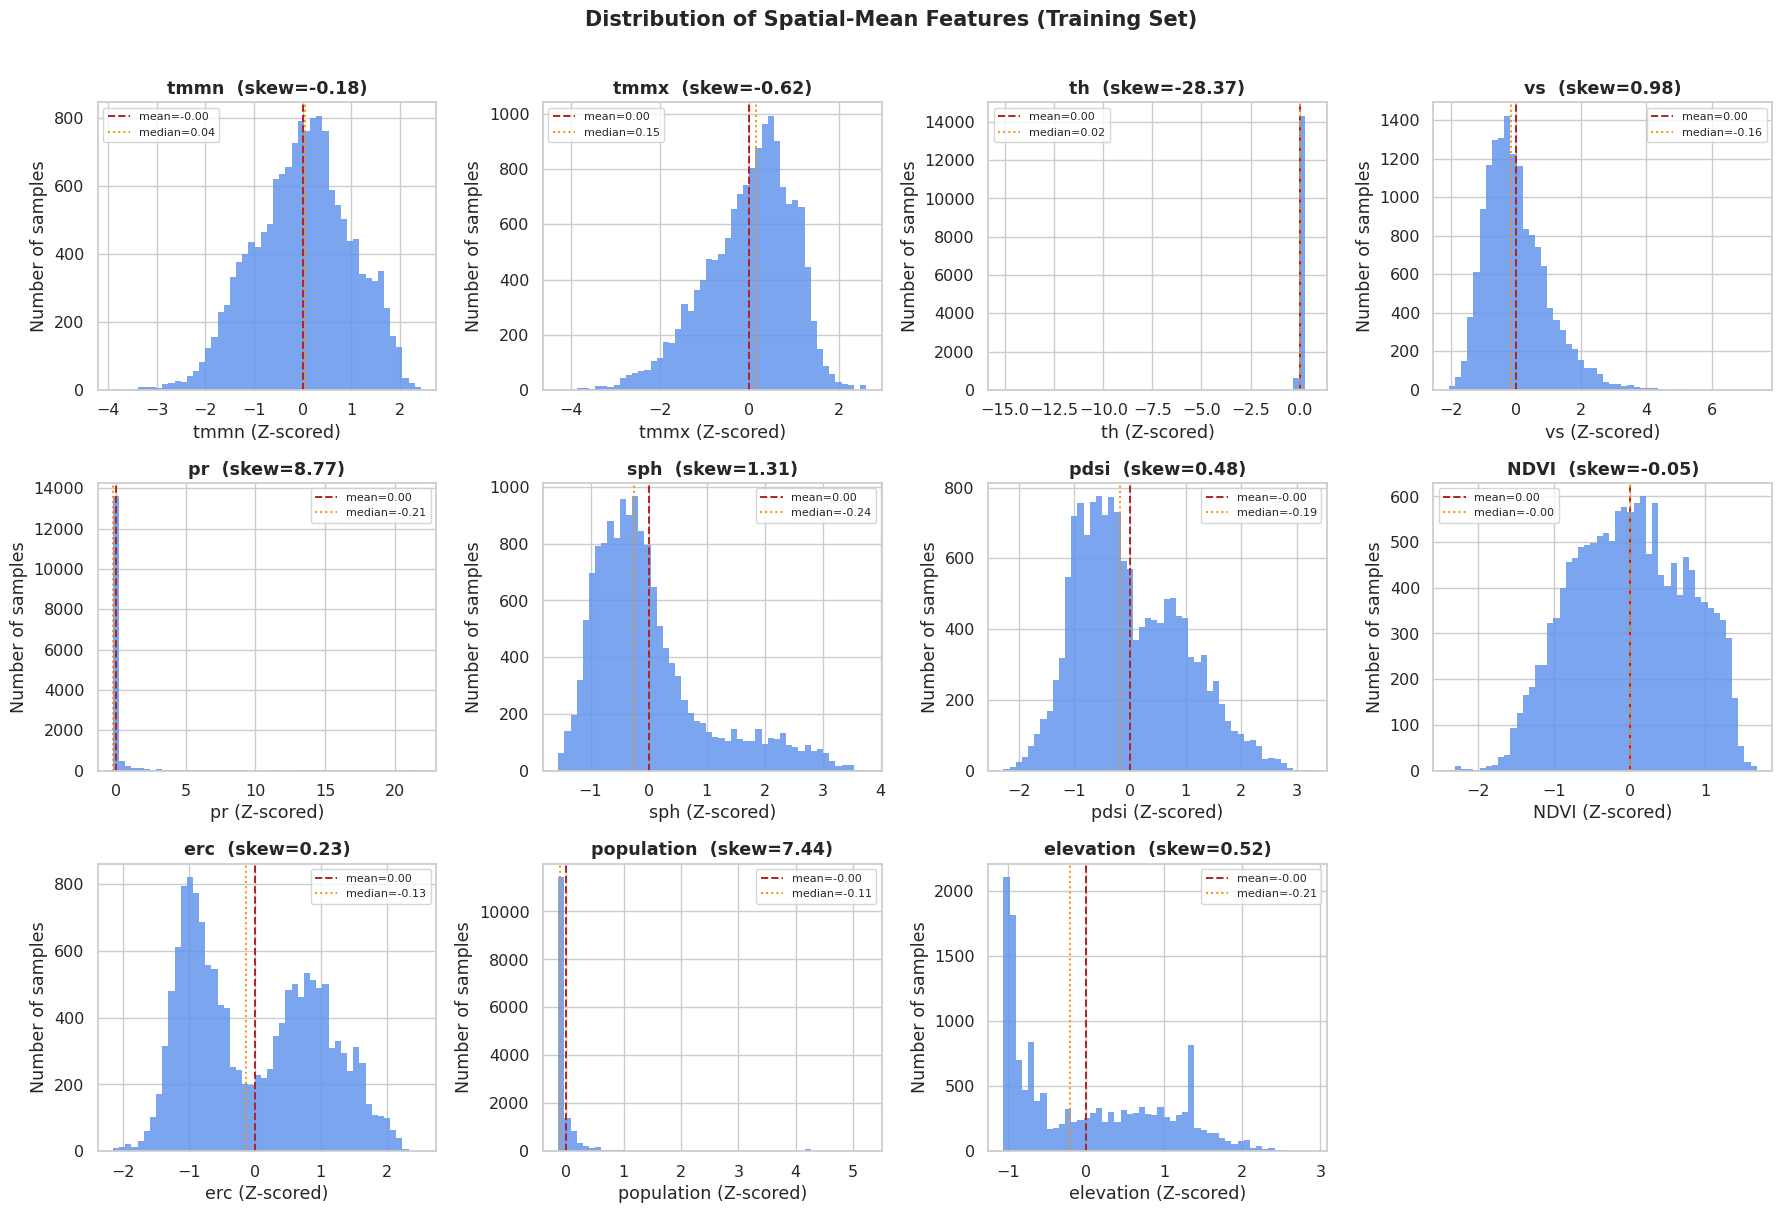

Skewness ranked (|skew| descending):
th            28.368
pr             8.767
population     7.439
sph            1.308
vs             0.983
tmmx           0.624
elevation      0.523
pdsi           0.482
erc            0.232
tmmn           0.181
NDVI           0.053


In [7]:
sns.set_theme(style='whitegrid', font_scale=1.05)

DIST_FEATURES = [f for f in INPUT_FEATURES if f != 'PrevFireMask']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

skew_vals = {}

for i, feature in enumerate(DIST_FEATURES):
    ax = axes[i]
    vals = df_train[feature].dropna()
    sk = skew(vals)
    skew_vals[feature] = sk

    ax.hist(vals, bins=50, color='cornflowerblue', edgecolor='none', alpha=0.85)
    ax.axvline(vals.mean(),   color='firebrick', lw=1.4, ls='--', label=f'mean={vals.mean():.2f}')
    ax.axvline(vals.median(), color='darkorange', lw=1.4, ls=':',  label=f'median={vals.median():.2f}')

    ax.set_xlabel(f"{feature} (Z-scored)")
    ax.set_ylabel("Number of samples")
    ax.set_title(f"{feature}  (skew={sk:.2f})", fontweight='bold')
    ax.legend(fontsize=8)

axes[-1].set_visible(False) 
fig.suptitle('Distribution of Spatial-Mean Features (Training Set)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Skewness ranked (|skew| descending):')
print(pd.Series(skew_vals).abs().sort_values(ascending=False).round(3).to_string())

#### Commentary on the above histogram and skew values:

One thing that stands out here is the histogram and skew for `th` (wind direction) - the histogram appears to be a single pike at 0 and its skew is 28.368, which is a very large value for a spatial mean. A potential reason for this is that wind direction is usually a value between 0 and 360 degrees, meaning `th` is a circular variable. In the data preprocessing, taking the averages of these wind direction values likely produced means that aren't representative of the data. Because this limitation will mainly affect EDA and may be unreliable in terms of data analysis, `th` won't be included in the following visualizations. 

Furthermore, `pr` (precipitation) and `population` both show a single bar with a small tail. These make sense given that most places have no rain or people on a given day. Also, the distribution for `erc` (Energy Release Component) is bimodal, suggesting that there could be two different seasonal fire-weather sets in the training data. Lastly, the distribution for `elevation` contains a spike along its tail, which could potentially reflect common terrains in fire-prone areas. 

The other features are all about symmetric with almost normal distributions, reflecting natural and expected weather data. 


## Box Plots

Below are box plots of the features for fire and no-fire samples, offering a look into how each features compares with itself.

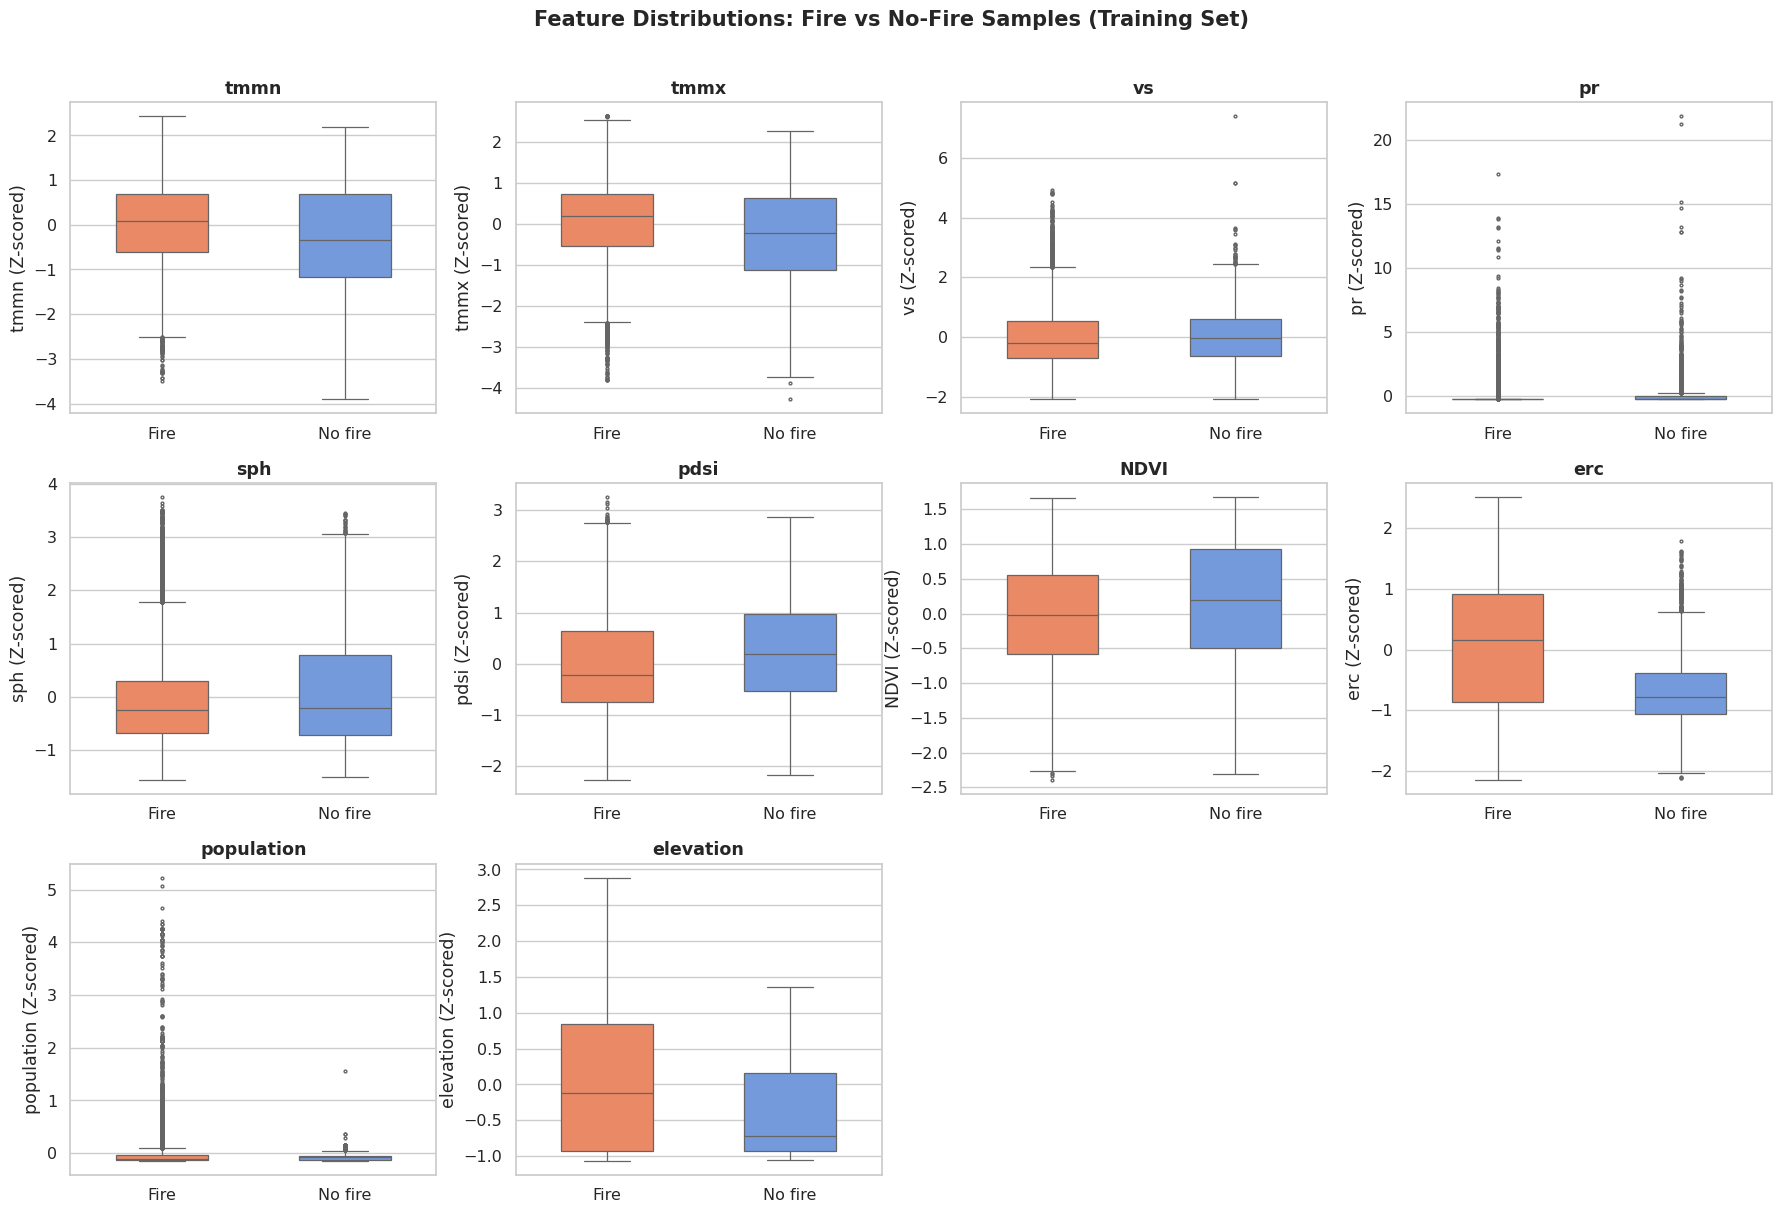

In [8]:
plot_df = df_train.copy()
plot_df['Fire Status'] = plot_df['has_fire'].map({0: 'No fire', 1: 'Fire'})

# Exclude th (due to unreliable spatial mean)
BOX_FEATURES = [f for f in DIST_FEATURES if f != 'th']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(BOX_FEATURES):
    ax = axes[i]
    sns.boxplot(
        data=plot_df, x='Fire Status', y=feat, hue='Fire Status', ax=ax,
        palette={'No fire': 'cornflowerblue', 'Fire': 'coral'},
        width=0.5, fliersize=2, linewidth=0.9,
        legend=False
    )
    ax.set_xlabel('')
    ax.set_ylabel(f"{feat} (Z-scored)")
    ax.set_title(feat, fontweight='bold')

# Hide unused subplot slots
for j in range(len(BOX_FEATURES), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distributions: Fire vs No-Fire Samples (Training Set)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### Commentary on the above box plots:

Some features, such as `erc` and `elevation`, show meaningful separation between the fire and no-fire samples. For `erc`, fire samples have a higher median and most of the box is above the box for the non-fire samples, suggesting that `erc` is a good predictor for fire-risk. For `elevation`, fire samples have a higher median than non-fire samples, suggesting that regions at a higher elevation may be more prone to wildfires than those at lower elevations. 

Also, `pdsi` and `NDVI` have fire samles with medians that are quite low, which matches environmental expectations that dry land is more prone to fire than wet land. 

The features `tmmn` and `tmmx` have fire samples that are slightly warmer than non-fire samples, which once again matches environmental expectations.

Lastly, `vs`, `sph`, `pr`, and `population` each have similar boxes for fire and no-fire samples, suggesting that at the spatial-level, these features won't strongly distinguish between fire and no-fire. 

## Correlation Analysis

Below is a heatmap that offers insight into how the features related to each other and to fire risk. The Pearson Correlation will tell us the strength of the linear relationship between two variables.

Included in the matrix is a variable called `fire_pixel_fraction` which tells us the fraction of the sample's pixels that "caught fire". It offers a quick look in the matrix at how well each feature relates to fire extent. 

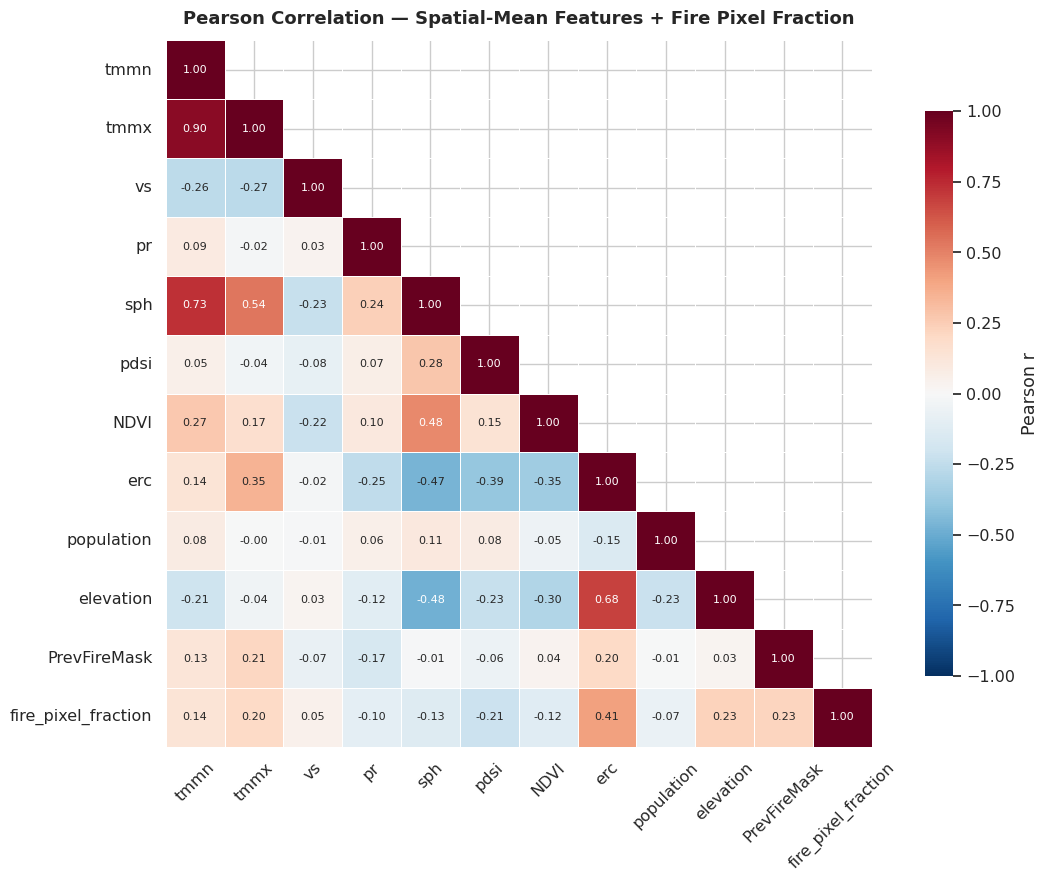

Correlation with fire_pixel_fraction (ranked by |r|):
erc             0.408
elevation       0.230
PrevFireMask    0.225
pdsi           -0.214
tmmx            0.203
tmmn            0.139
sph            -0.132
NDVI           -0.121
pr             -0.097
population     -0.070
vs              0.050


In [9]:
# Exclude th (unreliable spatial mean)
CORR_FEATURES = [f for f in INPUT_FEATURES if f != 'th']
corr_cols = CORR_FEATURES + ['fire_pixel_fraction']
corr_df   = df_train[corr_cols].dropna()
corr_mat  = corr_df.corr(method='pearson')

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)

sns.heatmap(
    corr_mat, ax=ax, mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
    square=True
)
ax.set_title('Pearson Correlation — Spatial-Mean Features + Fire Pixel Fraction', fontsize=13, fontweight='bold', pad=12)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

fire_corr = corr_mat['fire_pixel_fraction'].drop('fire_pixel_fraction').sort_values(key=abs, ascending=False)
print('Correlation with fire_pixel_fraction (ranked by |r|):')
print(fire_corr.round(3).to_string())

#### Commentary on the above correlation matrix:

Out of all features, `erc` appears to have the strongest correlation with `fire_pixel_fraction` suggesting that the fire risk rises with more fire-weather. Next, `elevation` and `PrevFireMask` have about the second-highest correlation with `fire_pixel_fraction`. It is a bit surprising that `PrevFireMask` has a relatively weaker correlation, but this suggests that its correlation with fire spread may be more non-linear. `pdsi` shows a negative correlation, which is expected given that with more drought, the fire risk is higher. 

The features `sph` and `tmmn` have a strong correlation because a higher humidity usually means a higher temperature. Also, `erc` and `elevation` have a correlation of 0.68, which makes sense given previous analysis. Areas with a higher elevation probably systematically have higher fire-danger ratings.

Lastly, `vs`, `pr`, and `population` all appear to be weak predictors of fire risk which tracks with the findings from the box plots. 

## Feature Importance using a Random Forest

This will help confirm the correlations we found in the above heatmap or offer some spots for further evaluation. For this section, "mean decrease in impurity"/MDI is used. This metric tell us how much a specific feature reduced impurity on average each time it was used across all trees in the Random Forest. So, a feature that scores 0.500 across 100 trees, for example, means that it caused about a 50% average reduction in impurity with each split. 

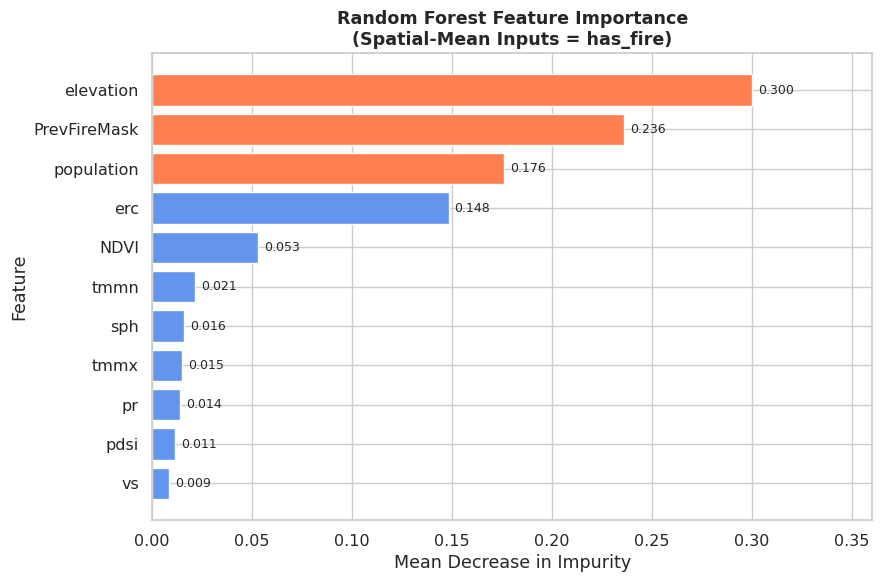

Ranked importance:
elevation       0.3001
PrevFireMask    0.2359
population      0.1762
erc             0.1482
NDVI            0.0530
tmmn            0.0213
sph             0.0161
tmmx            0.0150
pr              0.0141
pdsi            0.0114
vs              0.0086


In [15]:
# Exclude th (unreliable spatial mean)
RF_FEATURES = [f for f in INPUT_FEATURES if f != 'th']

rf_X = df_train[RF_FEATURES].fillna(0).values
rf_y = df_train['has_fire'].values

rf = RandomForestClassifier(
    n_estimators=200, max_depth=8, min_samples_leaf=10,
    class_weight='balanced', n_jobs=-1, random_state=42
)
rf.fit(rf_X, rf_y)

importances = pd.Series(rf.feature_importances_, index=RF_FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['coral' if v >= importances.quantile(0.75) else 'cornflowerblue' for v in importances]
bars = ax.barh(importances.index, importances.values, color=colors)

for bar, val in zip(bars, importances.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel("Mean Decrease in Impurity")
ax.set_ylabel("Feature")
ax.set_title("Random Forest Feature Importance\n(Spatial-Mean Inputs = has_fire)", fontweight='bold')
ax.set_xlim(0, importances.max() * 1.2)
plt.tight_layout()
plt.show()

print("Ranked importance:")
print(importances.sort_values(ascending=False).round(4).to_string())

#### Commentary on the above bar chart

In the above bar chart, `PrevFireMask` is near the top in terms of importance, which seemingly confirms the prediction made from the correlation matrix that the relationship between `PrevFireMask` and fire spread is non-linear. Also, `erc` is the fourth-highest important feature, emphasizing that is it a genuine predictor of fire-risk. The features `pr`, `pdsi`, and `vs` all have quite low importance, which follows with previous findings.

Also, `population` having the third highest decrease is a huge jump from the findings in the correlation matrix. Before, `population` didn't seem to have a relationship with fire risk but now appears to show contradicting findings.

Another thing that sticks out about the bar chart is `elevation` at the very top with the largest weight and `erc` much lower. In the correlation matrix, `elevation` was about the same as `PrevFireMask` and had a relatively high correlation of 0.68 with `erc`.  

Below, I investigate a little bit more into `elevation` and `population`.

In [ ]:
for feat in ['elevation', 'population']:
    fire_vals    = df_train.loc[df_train['has_fire'] == 1, feat]
    nofire_vals  = df_train.loc[df_train['has_fire'] == 0, feat]

    print(f'--- {feat} ---')
    print(f'  Fire: mean={fire_vals.mean():.3f}  median={fire_vals.median():.3f}  '
          f'std={fire_vals.std():.3f}  [{fire_vals.min():.2f}, {fire_vals.max():.2f}]')
    print(f'  No fire: mean={nofire_vals.mean():.3f}  median={nofire_vals.median():.3f}  '
          f'std={nofire_vals.std():.3f}  [{nofire_vals.min():.2f}, {nofire_vals.max():.2f}]')

    # Overlap check: what % of fire values fall within the no-fire IQR, 
    # and vice versa
    nofire_iqr = (nofire_vals.quantile(0.25), nofire_vals.quantile(0.75))
    pct_fire_in_nofire_iqr = ((fire_vals >= nofire_iqr[0]) & (fire_vals <= nofire_iqr[1])).mean() * 100
    print(f'  {pct_fire_in_nofire_iqr:.1f}% of fire samples fall within the no-fire IQR {tuple(round(x,2) for x in nofire_iqr)}')
    print()

# Cross-tab: does population/elevation correlate with source a sample came from?
# (this tests whether this is a sampling-region artifact
# rather than a real fire-risk relationship)
print('--- Quantile binning: does has_fire rate vary smoothly or jump sharply across bins? ---')
for feat in ['elevation', 'population']:
    df_train[f'{feat}_bin'] = pd.qcut(df_train[feat], q=5, duplicates='drop')
    bin_fire_rate = df_train.groupby(f'{feat}_bin', observed=True)['has_fire'].mean()
    print(f'\n{feat} — has_fire rate by quintile:')
    print(bin_fire_rate.round(3).to_string())
    df_train.drop(columns=[f'{feat}_bin'], inplace=True)

--- elevation ---
  Fire: mean=0.037  median=-0.113  std=0.951  [-1.06, 2.89]
  No fire: mean=-0.287  median=-0.716  std=0.875  [-1.05, 1.37]
  32.4% of fire samples fall within the no-fire IQR (np.float64(-0.93), np.float64(0.15))

--- population ---
  Fire: mean=0.008  median=-0.113  std=0.472  [-0.14, 5.23]
  No fire: mean=-0.059  median=-0.081  std=0.093  [-0.14, 1.56]
  30.2% of fire samples fall within the no-fire IQR (np.float64(-0.13), np.float64(-0.06))

--- Quantile binning: does has_fire rate vary smoothly or jump sharply across bins? ---

elevation — has_fire rate by quintile:
elevation_bin
(-1.0639999999999998, -0.946]    0.982
(-0.946, -0.657]                 0.661
(-0.657, 0.197]                  0.927
(0.197, 1.014]                   0.965
(1.014, 2.886]                   0.895

population — has_fire rate by quintile:
population_bin
(-0.143, -0.139]      0.973
(-0.139, -0.126]      0.873
(-0.126, -0.0871]     0.889
(-0.0871, -0.0103]    0.804
(-0.0103, 5.229]      0.893

Based on the above findings, the majority of training samples contains some fire regardless of `elevation` or `population`. Also, there is a 32%/30% IQR overlap of fire/no-fire, indicating that `elevation` and `population` don't have a genuine fire-risk relationship, and it potentially points towards a class imbalance. 

## Scatter Plots

For the scatter plots below, we will look at features that are "meaningful" based on the box plots, correlations, and random forest feature importance above. So, `th`, `elevation`, and `population` are not included here. 

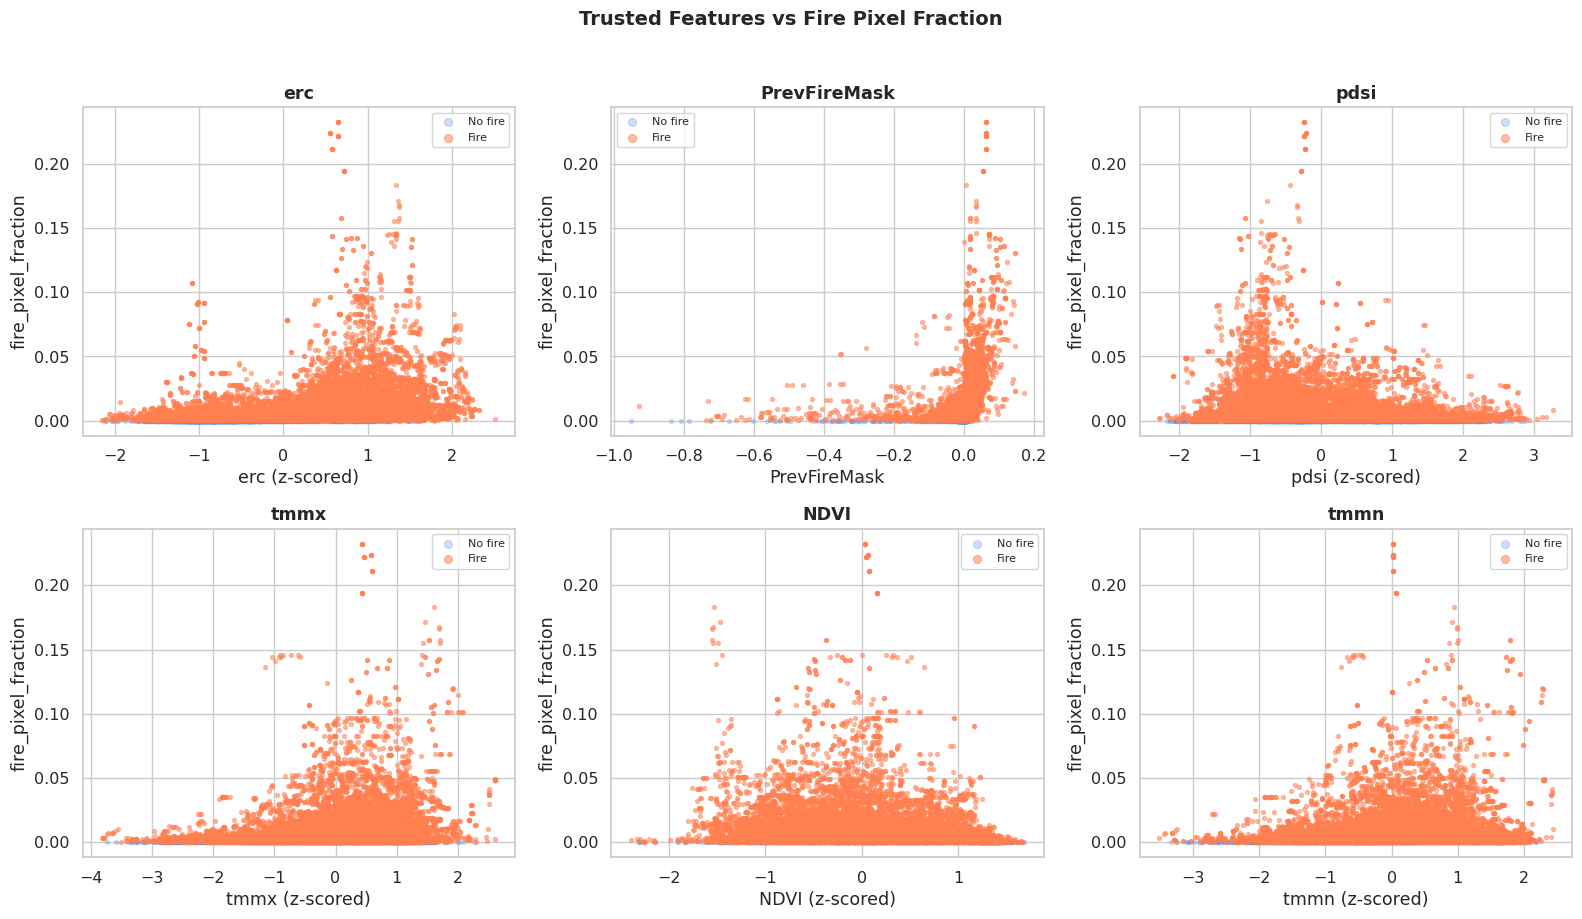

In [17]:
SCATTER_FEATURES = ['erc', 'PrevFireMask', 'pdsi', 'tmmx', 'NDVI', 'tmmn']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(SCATTER_FEATURES):
    ax = axes[i]
    x  = df_train[feat]
    y  = df_train['fire_pixel_fraction']
    hf = df_train['has_fire']

    ax.scatter(x[hf == 0], y[hf == 0], c='cornflowerblue', alpha=0.3, s=8, label='No fire')
    ax.scatter(x[hf == 1], y[hf == 1], c='coral', alpha=0.5, s=8, label='Fire')

    ax.set_xlabel(f'{feat} (z-scored)' if feat != 'PrevFireMask' else feat)
    ax.set_ylabel('fire_pixel_fraction')
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8, markerscale=2)

fig.suptitle('Trusted Features vs Fire Pixel Fraction', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Commentary on the above scatterplots:

Based on the scatterplots above, the one thing that sticks out is an imbalance - it appears that almost every point in each scatterplot is orange, and the blue points are almost not visible. This indicates that across these features, most of the training samples are classified as "Fire".

Besides this imbalance, the shapes of the plots provide some info, as well. The plot for `PrevFireMask` shows that this feature reaches its highest `fire_pixel_fraction` values around 0.0 to 0.2, emphasizing its importance for predicting next-day fire. Other features like `erc`, `tmmx`, and `tmmn` have points clustered above a z-score 0 which follows with our findings that when these values are higher, the fire-risk is higher. `pdsi` shows an inverse clustering, which makes sense given its negative correlation found earlier. `NDVI` has the most symmetrical distribution suggesting that vegetation health may not be the best predictor of fire spread. 

## Spatial Visualizations

For this step, we take a look at some samples, side-by-side with that sample's fire mask.

Plotting: largest fire (#11326, frac=0.2324), medium fire (#10869, frac=0.0052), no fire (#1, frac=0.0000)


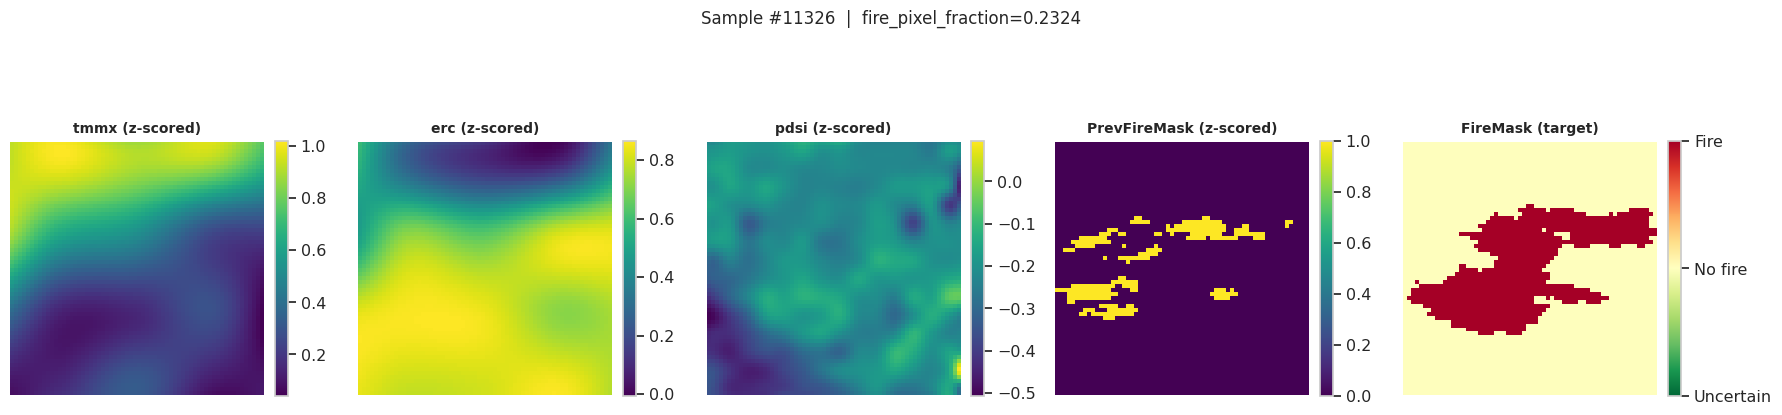

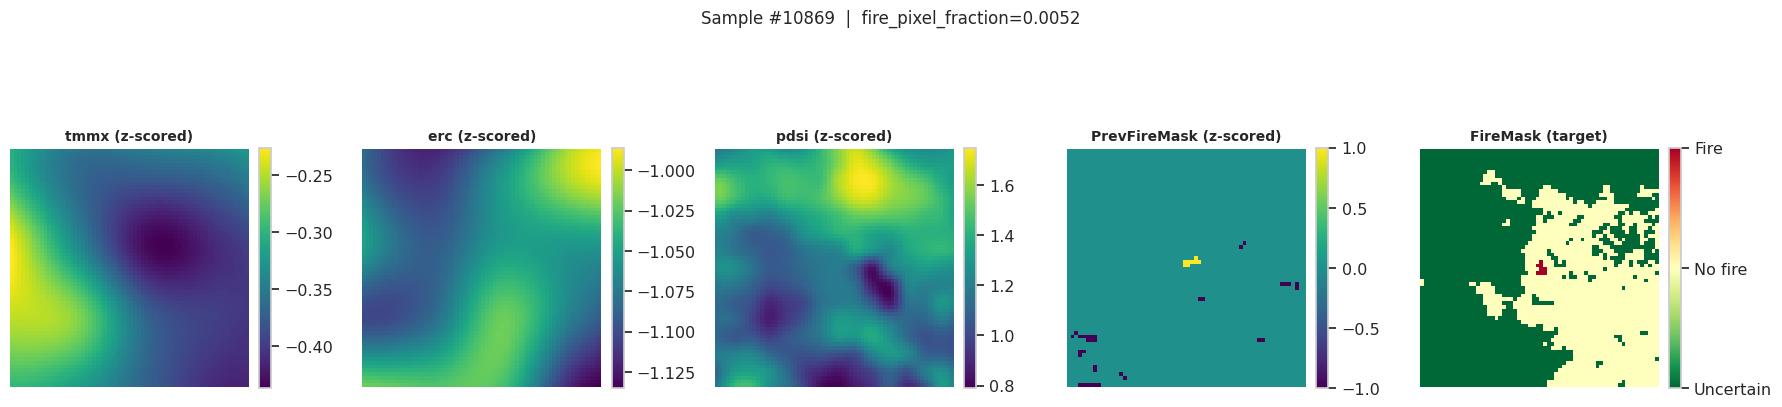

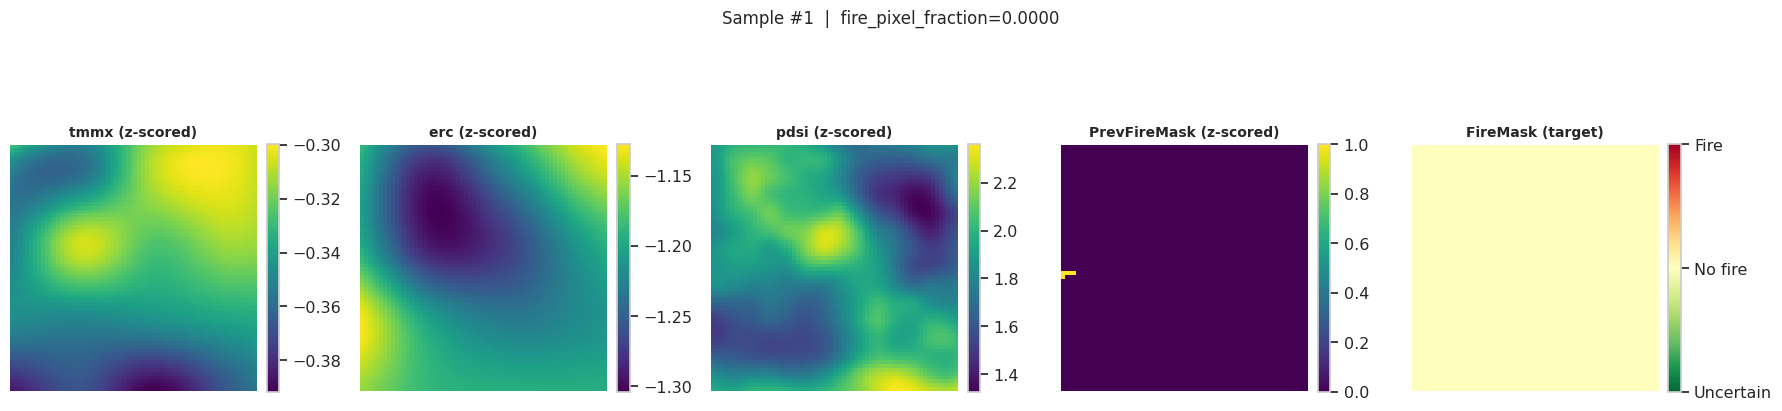

In [19]:
def plot_fire_scene(idx, show_features=('tmmx', 'erc', 'pdsi', 'PrevFireMask'), figsize=(18, 5)):
    ch_idx = [INPUT_FEATURES.index(f) for f in show_features]
    fig, axes = plt.subplots(1, len(show_features) + 1, figsize=figsize)

    for j, (feat, ci) in enumerate(zip(show_features, ch_idx)):
        ax = axes[j]
        im = ax.imshow(X_train[idx, :, :, ci], cmap='viridis')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(f'{feat} (z-scored)', fontweight='bold', fontsize=10)
        ax.axis('off')

    ax = axes[-1]
    im = ax.imshow(Y_train[idx], cmap='RdYlGn_r', vmin=-1, vmax=1)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=[-1, 0, 1])
    cbar.ax.set_yticklabels(['Uncertain', 'No fire', 'Fire'])
    ax.set_title('FireMask (target)', fontweight='bold', fontsize=10)
    ax.axis('off')

    fig.suptitle(
        f'Sample #{idx}  |  fire_pixel_fraction={df_train.loc[idx, "fire_pixel_fraction"]:.4f}',
        fontsize=12
    )
    plt.tight_layout()
    plt.show()


# Three illustrative samples: large fire, a medium-sized fire, and a no-fire scene
frac = df_train['fire_pixel_fraction'].values

large_idx   = int(np.nanargmax(frac))
fire_idxs   = np.where(frac > 0)[0]
median_idx  = fire_idxs[int(np.argmin(np.abs(frac[fire_idxs] - np.nanmedian(frac[fire_idxs]))))]
no_fire_idx = int(np.where(frac == 0)[0][0])

print(f'Plotting: largest fire (#{large_idx}, frac={frac[large_idx]:.4f}), '
      f'medium fire (#{median_idx}, frac={frac[median_idx]:.4f}), '
      f'no fire (#{no_fire_idx}, frac={frac[no_fire_idx]:.4f})')

for idx in [large_idx, median_idx, no_fire_idx]:
    plot_fire_scene(idx)

#### Commentary on the above visualizations:

##### Sample #11326: Largest Fire
In this visualization, the `PrevFireMask` panel has scattered patches of "fire", and the `FireMask` panel shows a single, connected patch of fire that has grown from the initial patches, clearly showing fire spread. Also, the `erc` panel has its highest values concentrated in areas where the fire actually developed, indicating that `erc` spatially coincides with where a fire might occur. 

##### Sample #10869: Median Fire
In this visualization, `PrevFireMask` shows almost no "fire" patches, but `FireMask` shows a small patch of "fire" in a region surrounded by "Uncertain" markings. This demonstrates how an "Uncertain" marker affects how we should interpret fire spread and how it varies from sample to sample. Areas that are marked "Uncertain" may not be random, but rather regions that were affected by some environmental condition, such as cloud covering. 

##### Sample #1: No Fire
In this visualization, the values for `erc` and `tmmx` are on the lower side, and `PrevFireMask` is almost entirely empty, which follows with our findings that calmer conditions produce little fire spread. 

## Analysis of Class Imbalances

This analysis will offer insight into how the classes (at both the sample- and pixel- levels) differ from each other.

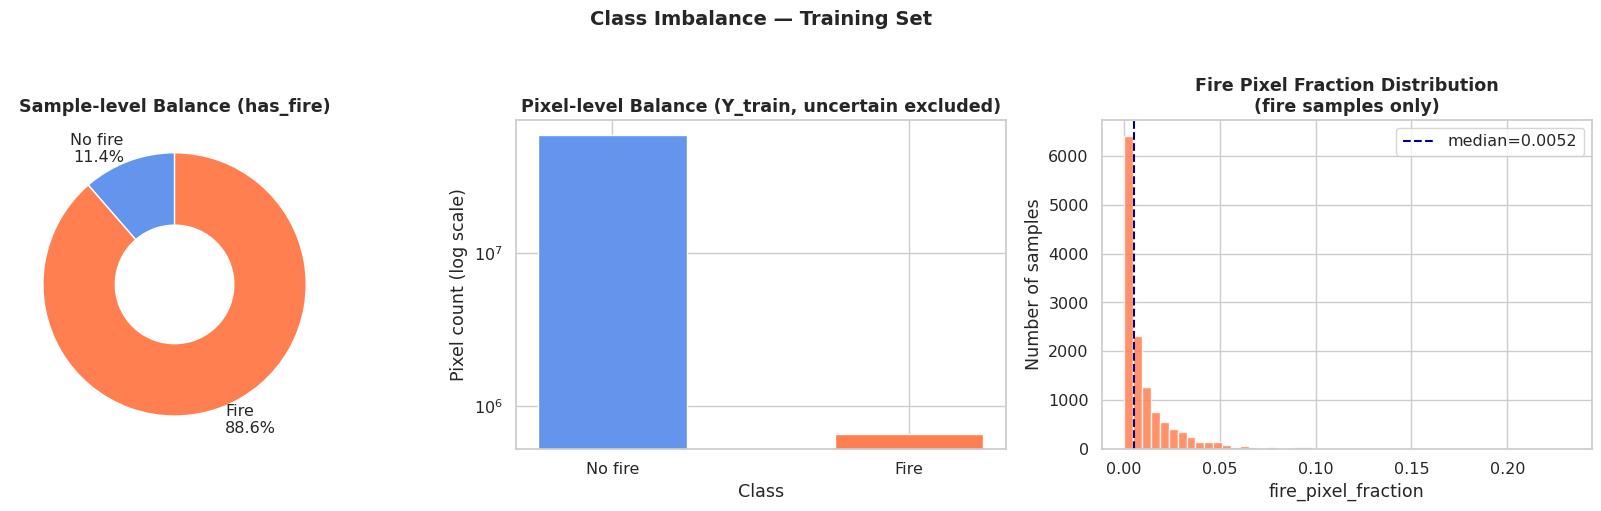

Sample-level: 11.4% no-fire / 88.6% fire
Pixel-level:  98.90% no-fire / 1.10% fire  -> 90.0:1 ratio


In [20]:
fire_counts = df_train['has_fire'].value_counts().sort_index()
fire_pcts   = fire_counts / len(df_train) * 100

total_valid  = valid_mask.sum()
total_fire   = fire_pixels.sum()
total_nofire = total_valid - total_fire
pct_fire_px  = total_fire / total_valid * 100

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].pie(
    fire_counts.values,
    labels=[f'No fire\n{fire_pcts[0]:.1f}%', f'Fire\n{fire_pcts[1]:.1f}%'],
    colors=['cornflowerblue', 'coral'], startangle=90, wedgeprops=dict(width=0.55)
)
axes[0].set_title('Sample-level Balance (has_fire)', fontweight='bold')

axes[1].bar(['No fire', 'Fire'], [total_nofire, total_fire], color=['cornflowerblue', 'coral'], width=0.5)
axes[1].set_yscale('log')
axes[1].set_ylabel('Pixel count (log scale)')
axes[1].set_xlabel('Class')
axes[1].set_title('Pixel-level Balance (Y_train, uncertain excluded)', fontweight='bold')

frac_fire = df_train.loc[df_train['has_fire'] == 1, 'fire_pixel_fraction']
axes[2].hist(frac_fire, bins=50, color='coral', alpha=0.85)
axes[2].set_xlabel('fire_pixel_fraction')
axes[2].set_ylabel('Number of samples')
axes[2].set_title('Fire Pixel Fraction Distribution\n(fire samples only)', fontweight='bold')
axes[2].axvline(frac_fire.median(), color='navy', ls='--', label=f'median={frac_fire.median():.4f}')
axes[2].legend()

fig.suptitle('Class Imbalance — Training Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

px_imbalance = total_nofire / total_fire
print(f'Sample-level: {fire_pcts[0]:.1f}% no-fire / {fire_pcts[1]:.1f}% fire')
print(f'Pixel-level:  {100-pct_fire_px:.2f}% no-fire / {pct_fire_px:.2f}% fire  -> {px_imbalance:.1f}:1 ratio')

#### Commentary on the above visualizations:

We see that 88.6% of the training samples contain at least one fire pixel, which follows with the large imbalance found earlier in the Random Forest analysis and scatterplots. However, when looking at the pixels, only 1.10% of all pixels are actually on fire, indicating a huge imbalance, 90:1, that favors no-fire. In the right-most panel, the histogram shows that the among samples that do contain fire, the median of `fire_pixel_fraction` is 0.0052. This means that half of the samples that contain fire actually have fire in 0.52% of their pixels.

Overall, there is a sample-level imbalance that is mild enough to ignore, but the pixel-level imbalance is quite large and might need to be handled separately in the model. Also, evaluation of the model may need to rely on precision or recall metrics instead of accuracy since a model that predicts "no fire" would achieve about 99% accuracy without really telling us anything.

## EDA Summary and Conclusions
Below are a few important findings:
- The most consistent fire-spread predictors are `erc`, `PrevFireMask`
- The features `pdsi`, `tmmn`, and `tmmx` show a weak but real relationship with fire-spread.
- The features `elevation` and `population` do appear important for predicting fire-spread but further evaluation found that this is due to the class imbalances.
- The sample-level class imbalance is mild, but the pixel-level class imbalance is more severe and might require different handling when building the model.